# Road-Scene Semantic Segmentation with U-Net

This notebook builds and trains a **U-Net** for semantic segmentation of autonomous-driving scenes.  
The input is an RGB road image, and the output is a **class prediction for every pixel**.

Unlike object detection, which places a bounding box around an object, semantic segmentation tries to answer a more detailed question:

> **What class does each pixel belong to?**

The workflow in this notebook is:

`RGB image → preprocessing → U-Net → pixel-wise class scores → predicted segmentation mask`

The project also uses separate training, validation, and test sets so that model performance can be checked on images that were not used to update the model weights.

In [1]:
# Core libraries
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Dropout,Conv2DTranspose,concatenate
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

# Reproducibility and project configuration
SEED = 42
IMG_HEIGHT = 96
IMG_WIDTH = 128
NUM_CHANNELS = 3
NUM_CLASSES = 23
BATCH_SIZE = 32
EPOCHS = 40

tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)

2026-08-17 15:45:14.465098: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-17 15:45:14.522492: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-17 15:45:15.322580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0


## 1. Dataset structure

The dataset contains **1,060 paired road-scene images and segmentation masks**:

```text
data/
├── CameraRGB/
└── CameraMask/
```

- **CameraRGB** contains the normal color images seen by the camera.
- **CameraMask** contains the ground-truth segmentation labels.

The two folders use matching filenames. For example, an RGB image and its mask describe the **same scene**.

During training:

```text
CameraRGB image
      ↓
    U-Net
      ↓
predicted mask
      ↓
compare with CameraMask
      ↓
      loss
```

Keeping the image and mask paired correctly is essential. If an image were matched with the wrong mask, the model would be trained against an incorrect target.

In [2]:
# Project and dataset paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

image_path = PROJECT_ROOT / "data" / "CameraRGB"
mask_path = PROJECT_ROOT / "data" / "CameraMask"

# Check that both folders exist
if not image_path.exists() or not mask_path.exists():
    raise FileNotFoundError("CameraRGB or CameraMask folder was not found.")

# Get image filenames
image_names = sorted(os.listdir(image_path))

# Create matching image and mask paths
image_list = [str(image_path / name) for name in image_names]
mask_list = [str(mask_path / name) for name in image_names]

# Check that every image has a matching mask
for mask_file in mask_list:
    if not Path(mask_file).exists():
        raise ValueError(f"Matching mask not found: {mask_file}")

print("Project root:", PROJECT_ROOT)
print("Number of image/mask pairs:", len(image_list))


Project root: /home/roozbeh/projects/Autonomous-driving-semantic-segmentation
Number of image/mask pairs: 1060


## 2. Preview an image and its segmentation mask

Before building the TensorFlow pipeline, one image-mask pair is displayed.

This is a simple data-quality check:

- the RGB image should show the road scene,
- the mask should describe the same scene,
- each mask value represents a semantic class rather than an RGB color intensity.

The mask is the **target** that the U-Net will learn to predict.

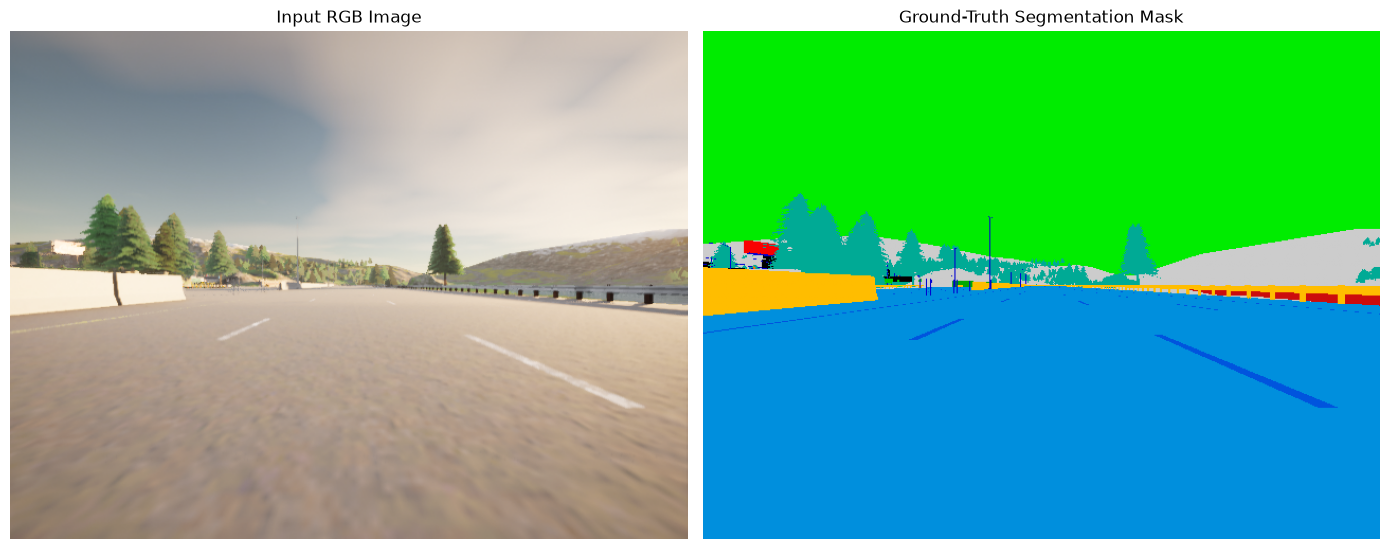

In [3]:
N = min(2, len(image_list) - 1)

img = imageio.imread(image_list[N])
mask = imageio.imread(mask_list[N])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].set_title("Input RGB Image")
axes[0].axis("off")

axes[1].imshow(mask[:, :, 0], cmap="nipy_spectral")
axes[1].set_title("Ground-Truth Segmentation Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Preprocessing

The raw image and mask are read from disk and converted into tensors before they are sent to the model.

The RGB image and segmentation mask need different resizing methods:

- **RGB image → bilinear interpolation.** Color values are continuous, so interpolation between neighboring pixels is acceptable.
- **Mask → nearest-neighbor interpolation.** A mask contains discrete class IDs. Blending class IDs could create invalid values such as `4.6`, which is not a valid class.

`tf.image.convert_image_dtype(..., tf.float32)` also converts the RGB pixel values to floating-point values in the range `0–1`.

The final shapes used by the model are:

```text
Image: 96 × 128 × 3
Mask:  96 × 128 × 1
```

In [4]:
def process_path(image_path, mask_path):
    """Read one RGB image and its segmentation mask from disk."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.math.reduce_max(mask, axis=-1, keepdims=True)

    return image, mask


def preprocess(image, mask):
    """Resize the image/mask pair while preserving discrete mask labels."""
    image = tf.image.resize(image,(IMG_HEIGHT, IMG_WIDTH),method="bilinear",)
    mask = tf.image.resize(mask,(IMG_HEIGHT, IMG_WIDTH),method="nearest",)
    mask = tf.cast(mask, tf.int32)

    return image, mask


### What happens to one image-mask pair?

`process_path()` and `preprocess()` perform two different stages.

```text
file paths
   ↓
process_path()
   ├─ read PNG image
   ├─ convert RGB values to float 0–1
   ├─ read PNG mask
   └─ reduce the mask to one class-ID channel
   ↓
(image tensor, mask tensor)
   ↓
preprocess()
   ├─ resize RGB image with bilinear interpolation
   ├─ resize mask with nearest-neighbor interpolation
   └─ cast mask labels to integer
   ↓
96×128×3 image + 96×128×1 mask
```

The image and its mask always travel through the pipeline as a pair.


### Reproducible train / validation / test split

The 1,060 image-mask pairs are randomly divided into three groups:

```text
848 training pairs      (80%)
106 validation pairs    (10%)
106 test pairs          (10%)
```

The same shuffled indices are used for both `image_list` and `mask_list`, so the image-mask pairing is preserved.

The three sets have different jobs:

- **Training set:** updates the model weights.
- **Validation set:** checks performance during training and is used by the callbacks.
- **Test set:** stays separate until the final evaluation.

This separation helps us measure whether the model can generalize beyond the images used for learning.

In [5]:
# Shuffle the indices so the split is random
np.random.seed(SEED)
indices = np.random.permutation(len(image_list))

# Calculate split sizes
n_total = len(indices)
n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

# Split the indices
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

# Use the same indices for images and masks
train_images = [image_list[i] for i in train_idx]
train_masks = [mask_list[i] for i in train_idx]

val_images = [image_list[i] for i in val_idx]
val_masks = [mask_list[i] for i in val_idx]

test_images = [image_list[i] for i in test_idx]
test_masks = [mask_list[i] for i in test_idx]

print("Train pairs:", len(train_images))
print("Validation pairs:", len(val_images))
print("Test pairs:", len(test_images))


Train pairs: 848
Validation pairs: 106
Test pairs: 106


In [6]:
AUTOTUNE = tf.data.AUTOTUNE


def build_dataset(image_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()

    if training:
        ds = ds.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_dataset = build_dataset(train_images, train_masks, training=True)
val_dataset = build_dataset(val_images, val_masks, training=False)
test_dataset = build_dataset(test_images, test_masks, training=False)

print("Training element spec:", train_dataset.element_spec)

# Sanity-check the label range on one batch.
for _, sample_masks in train_dataset.take(1):
    min_label = int(tf.reduce_min(sample_masks))
    max_label = int(tf.reduce_max(sample_masks))
    print(f"Sample mask label range: {min_label} to {max_label}")
    if min_label < 0 or max_label >= NUM_CLASSES:
        raise ValueError(
            f"Mask labels must be between 0 and {NUM_CLASSES - 1}, "
            f"but found {min_label} to {max_label}."
        )


I0000 00:00:1787006716.561720   32210 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Training element spec: (TensorSpec(shape=(None, 96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 128, 1), dtype=tf.int32, name=None))
Sample mask label range: 1 to 22


2026-08-17 15:45:18.846005: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### How the `tf.data` pipeline works

`build_dataset()` is a helper function that applies the same preparation steps to the training, validation, and test lists.

Its flow is:

```text
Python lists of file paths
        ↓
from_tensor_slices()
        ↓
process_path()
        ↓
preprocess()
        ↓
cache()
        ↓
shuffle()        ← training set only
        ↓
batch(32)
        ↓
prefetch()
```

`batch(32)` groups up to 32 image-mask pairs into one training step.

`prefetch()` prepares upcoming batches while the current batch is being processed, which can reduce waiting time.

Only the training dataset is shuffled. Validation and test data do not need shuffling because their purpose is evaluation rather than weight updates.


# 4. U-Net Architecture

U-Net has an **encoder**, a **bottleneck**, and a **decoder**.

### Encoder: learn *what* is in the image
The encoder repeatedly applies convolution and max pooling.

As we move deeper:

```text
Height & width:   decrease
Feature channels: increase

32 → 64 → 128 → 256 → 512
```

The smaller spatial maps summarize larger regions of the image, while the larger number of channels allows the network to learn more types of features.

### Decoder: restore *where* those features belong
The decoder reverses the spatial compression.

As we move upward:

```text
Height & width:   increase
Feature channels: decrease

512 → 256 → 128 → 64 → 32
```

At each decoder level, a **skip connection** brings back a high-resolution feature map from the matching encoder level. This helps recover spatial detail that may have been weakened by pooling.

## 5. Encoder block

`conv_block()` is the basic building block of the encoder.

It performs:

```text
Input
  ↓
3×3 Conv + ReLU
  ↓
3×3 Conv + ReLU
  ↓
optional Dropout
  ├────────────→ skip_connection
  ↓
2×2 Max Pool
  ↓
next_layer
```

The function returns **two tensors**:

- `next_layer`: the pooled tensor that goes deeper into the encoder.
- `skip_connection`: the tensor saved **before pooling** and later sent to the decoder.

Using `padding="same"` keeps height and width unchanged during the two convolutions. The spatial size changes only when max pooling is applied.

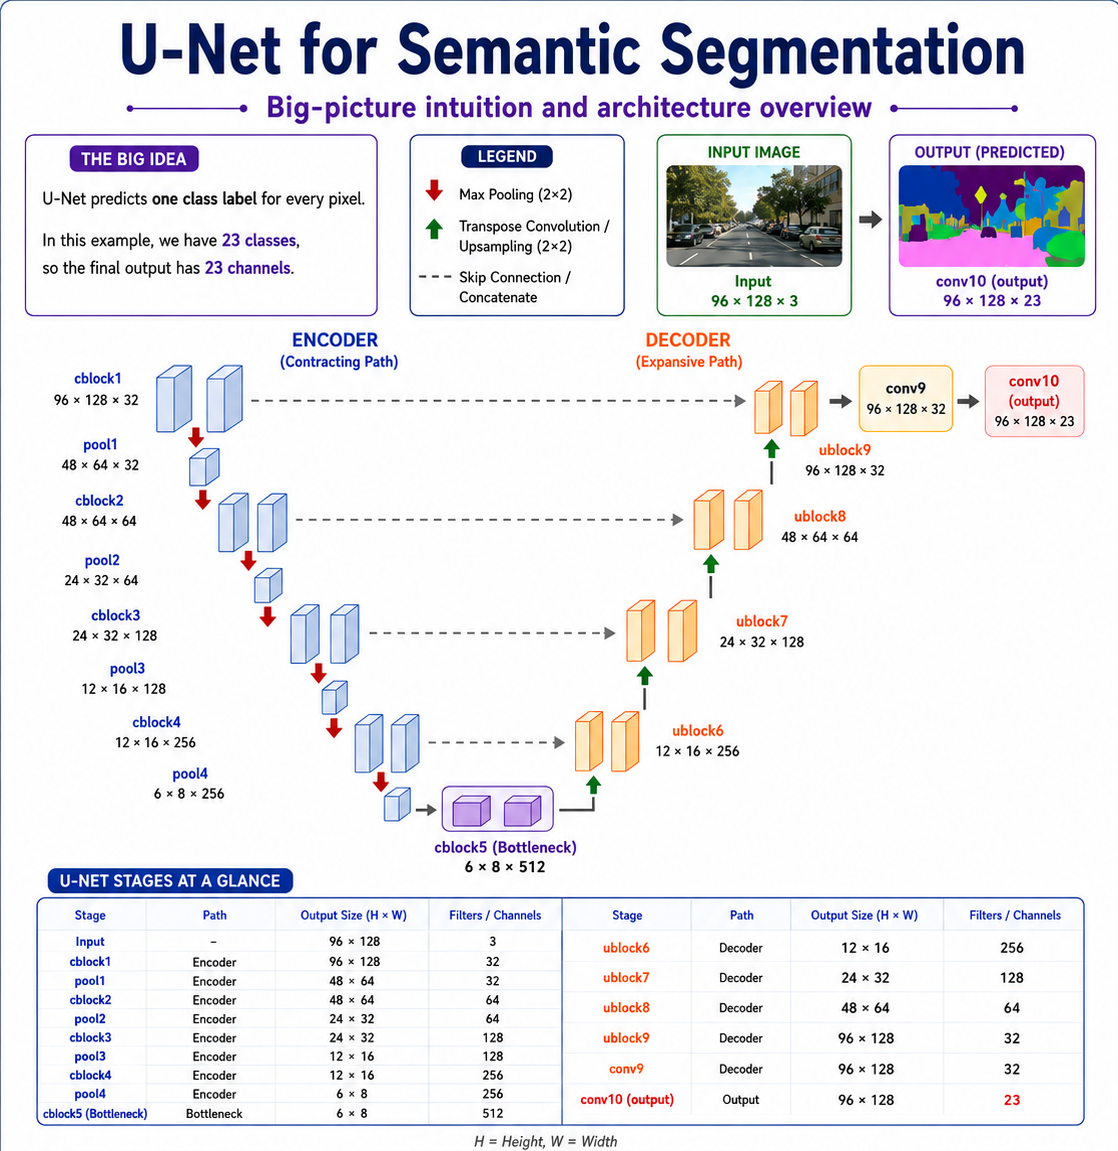

In [7]:
def conv_block(inputs=None,n_filters=32,dropout_prob=0,max_pooling=True):
    """
    Convolutional downsampling block.
    """

    # First 3×3 convolution
    conv = Conv2D(n_filters,3,activation="relu",padding="same",kernel_initializer="he_normal")(inputs)

    # Second 3×3 convolution
    conv = Conv2D( n_filters,3,activation="relu",padding="same",kernel_initializer="he_normal")(conv)

    # Optional regularization in deeper blocks
    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)

    # Save high-resolution representation for skip connection
    skip_connection = conv

    # Downsample for the next encoder block
    if max_pooling:
        next_layer = MaxPooling2D(pool_size=(2, 2))(conv)
    else:
        next_layer = conv

    return next_layer, skip_connection

### Why do filters double in the encoder?

After a `2×2` max-pooling operation, height and width are each divided by two.

For example:

```text
96 × 128 × 32
       ↓ MaxPool
48 × 64 × 32
```

At the next encoder level, we choose more filters:

```text
48 × 64 × 64
```

So the general pattern is:

```text
spatial resolution ↓
feature channels   ↑
```

The increase in channels is a **design choice**, not a mathematical requirement of max pooling. It gives the deeper network more feature maps for representing more abstract patterns while the spatial maps become smaller.

In [8]:
example_input = Input((96, 128, 3))
example_next, example_skip = conv_block(example_input, n_filters=32)

print("skip_connection:", example_skip.shape)
print("next_layer after pooling:", example_next.shape)

skip_connection: (None, 96, 128, 32)
next_layer after pooling: (None, 48, 64, 32)


### Encoder shape example

The test above starts with:

```text
Input: 96 × 128 × 3
```

With `n_filters=32`, the first convolution creates 32 feature maps:

```text
96 × 128 × 3
   ↓ Conv2D(32)
96 × 128 × 32
   ↓ Conv2D(32)
96 × 128 × 32   ← saved as skip_connection
   ↓ MaxPool(2×2)
48 × 64 × 32    ← next_layer
```

Notice that the convolutions change the **channel count**, while `padding="same"` keeps height and width unchanged. Max pooling then halves height and width but does not change the number of channels.


## 6. Decoder / upsampling block

The decoder must increase the spatial resolution and combine deep features with detailed encoder features.

The first operation is `Conv2DTranspose`.

Two arguments control two different things:

```text
strides=(2, 2)  → controls height and width
filters         → controls the number of output channels
```

So if the input is:

```text
6 × 8 × 512
```

and the layer uses:

```text
stride = 2
filters = 256
```

the output becomes:

```text
12 × 16 × 256
```

The **doubling of height and width** comes from `stride=2`.  
The **reduction from 512 channels to 256 channels** happens because we explicitly asked the layer to produce 256 filters. It is an architectural choice; `Conv2DTranspose` does not automatically halve the channels.

The upsampled tensor is then concatenated with the matching encoder skip connection, and two normal `3×3` convolutions refine the merged features.

In [9]:
def upsampling_block(expansive_input,contractive_input,n_filters=32):
    """
    Convolutional upsampling block.
    """

    # Double spatial resolution
    up = Conv2DTranspose(n_filters,3,strides=(2, 2),padding="same")(expansive_input)

    # Combine decoder features with the matching encoder features
    merge = concatenate([up, contractive_input],axis=3)

    # Refine merged features
    conv = Conv2D(n_filters,3,activation="relu",padding="same",kernel_initializer="he_normal")(merge)

    conv = Conv2D(n_filters,3,activation="relu",padding="same",kernel_initializer="he_normal")(conv)

    return conv

### Why does the skip connection use the tensor before max pooling?

The decoder can only concatenate two tensors when their height and width match.

For example, suppose a decoder tensor is upsampled to:

```text
24 × 32 × ...
```

The matching encoder tensor must also have spatial size:

```text
24 × 32 × ...
```

That matching encoder representation is the tensor **before max pooling**. The pooled version would already be smaller.

The skip connection therefore serves two purposes:

1. it provides a tensor with the correct spatial resolution for concatenation,
2. it returns detailed spatial information that could be lost during repeated downsampling.

In [10]:
expansive_input = Input((12, 16, 256))
contractive_input = Input((24, 32, 128))

example_up = upsampling_block(expansive_input,contractive_input,n_filters=32)

print("Upsampling block output:", example_up.shape)

Upsampling block output: (None, 24, 32, 32)


### Decoder shape example

The test above uses:

```text
expansive_input:   12 × 16 × 256
contractive_input: 24 × 32 × 128
n_filters: 32
```

Step 1 — transposed convolution:

```text
12 × 16 × 256
   ↓ Conv2DTranspose(filters=32, stride=2)
24 × 32 × 32
```

`stride=2` doubles the spatial dimensions.  
`filters=32` chooses 32 output channels.

Step 2 — concatenate with the encoder skip tensor:

```text
24 × 32 × 32
        +
24 × 32 × 128
        ↓ concatenate channels
24 × 32 × 160
```

Step 3 — two normal convolutions:

```text
24 × 32 × 160
   ↓ Conv2D(32)
24 × 32 × 32
   ↓ Conv2D(32)
24 × 32 × 32
```

This is why the printed output of the block is `(None, 24, 32, 32)`. `None` is the batch dimension.


## 7. Build the complete U-Net

The complete model connects the encoder blocks, bottleneck, decoder blocks, and final pixel classifier.

The architecture used here has:

- four encoder levels with max pooling,
- one bottleneck with no additional pooling,
- four decoder levels,
- one final feature-refinement convolution,
- one `1×1` convolution that converts the final features into class scores.

Dropout is used in the deeper encoder block and the bottleneck as regularization.

The important idea is that the encoder compresses the image while learning richer features, and the decoder restores the original spatial resolution while using the skip connections to recover detail.

In [11]:
def unet_model(input_size=(96, 128, 3),n_filters=32,n_classes=23):
    """
    Build a U-Net semantic segmentation model.
    """

    inputs = Input(input_size)

    # -------------------------
    # Encoder / contracting path
    # -------------------------
    cblock1 = conv_block(inputs,n_filters)
    cblock2 = conv_block(cblock1[0],n_filters * 2)
    cblock3 = conv_block(cblock2[0],n_filters * 4)
    cblock4 = conv_block(cblock3[0],n_filters * 8,dropout_prob=0.3)

    # -------------------------
    # Bottleneck
    # -------------------------
    cblock5 = conv_block(cblock4[0],n_filters * 16,dropout_prob=0.3, max_pooling=False)

    # -------------------------
    # Decoder / expansive path
    # -------------------------
    ublock6 = upsampling_block(cblock5[0],cblock4[1], n_filters * 8)
    ublock7 = upsampling_block(ublock6,cblock3[1],n_filters * 4)
    ublock8 = upsampling_block(ublock7,cblock2[1],n_filters * 2)
    ublock9 = upsampling_block(ublock8,cblock1[1],n_filters)

    # Final feature refinement
    conv9 = Conv2D(n_filters,3,activation="relu",padding="same",kernel_initializer="he_normal")(ublock9)

    # Pixel-wise classifier:
    # 1×1 kernel maps feature channels to class scores
    conv10 = Conv2D(n_classes,1,padding="same")(conv9)

    model = tf.keras.Model(inputs=inputs,outputs=conv10)

    return model

### Shape flow through this U-Net

With input size `96×128×3` and 32 base filters, the model follows this shape pattern:

| Stage | Main output / saved feature |
|---|---|
| Input | `96×128×3` |
| Encoder 1 | skip `96×128×32`, pool → `48×64×32` |
| Encoder 2 | skip `48×64×64`, pool → `24×32×64` |
| Encoder 3 | skip `24×32×128`, pool → `12×16×128` |
| Encoder 4 | skip `12×16×256`, pool → `6×8×256` |
| Bottleneck | `6×8×512` |
| Decoder 1 | `12×16×256` |
| Decoder 2 | `24×32×128` |
| Decoder 3 | `48×64×64` |
| Decoder 4 | `96×128×32` |
| Final output | `96×128×23` |

The decoder channel counts are intentionally reduced as spatial resolution grows. This is a design choice that mirrors the encoder:

```text
Encoder:  resolution ↓, channels ↑
Decoder:  resolution ↑, channels ↓
```

The model summary reports **8,640,471 trainable parameters**.


### Why is the final convolution 1×1?

Most convolutions in the network use `3×3` kernels because they need to learn spatial patterns from neighboring pixels.

The last layer has a different job. By that point, the decoder has already restored the image to:

```text
96 × 128 × 32
```

At every pixel there is now a vector of **32 learned features**.

A `1×1` convolution combines those 32 values and produces **23 class scores** for the same pixel:

```text
96 × 128 × 32
        ↓ 1×1 Conv, 23 filters
96 × 128 × 23
```

The height and width do not change. Only the channel dimension changes from learned features to class scores.

In [12]:
unet = unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS),n_filters=32,n_classes=NUM_CLASSES,)

unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 128,   │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 96, 128,   │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 64,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 48, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 48, 64,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 24, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 24, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 24, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 12, 16,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 12, 16,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 12, 16,    │    590,080 │ conv2d_10[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 16,    │          0 │ conv2d_11[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 6, 8, 256) │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 6, 8, 512) │  1,180,160 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 6, 8, 512) │  2,359,808 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 8, 512) │          0 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 12, 16,    │  1,179,904 │ dropout_1[0][0] 

 Total params: 8,640,471 (32.96 MB)

 Trainable params: 8,640,471 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile the model

Semantic segmentation can be treated as **multiclass classification at every pixel**.

The loss function is:

`SparseCategoricalCrossentropy(from_logits=True)`

`Sparse` is appropriate because each target pixel stores a single integer class ID rather than a one-hot vector.

`from_logits=True` is used because the final U-Net layer returns raw class scores (**logits**) and does not contain a softmax activation.

During `model.fit()`, this notebook tracks **pixel accuracy**:

```text
correctly classified pixels
----------------------------
total number of pixels
```

Pixel accuracy is useful and easy to understand, but it can be overly optimistic when large classes occupy most of an image. For that reason, **Mean IoU is calculated separately on the test set after training**.

In [13]:
unet.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=["accuracy"])

## 9. Train with validation-aware callbacks

The model is trained on `train_dataset` while `val_dataset` is evaluated after every epoch.

Three Keras callbacks are configured:

- `ModelCheckpoint` saves the model whenever validation loss reaches a new best value.
- `ReduceLROnPlateau` reduces the learning rate when validation loss stops improving enough for the configured patience period.
- `EarlyStopping` can stop training if validation loss fails to improve for several epochs and restores the best weights.

In this run, all **40 requested epochs** were completed because validation loss continued reaching new best values through the final epoch. `ReduceLROnPlateau` lowered the learning rate several times during training, which helped the model continue making smaller improvements later in the run. `EarlyStopping` did not trigger because validation loss kept improving before its patience limit was reached.

The warning saying that `shuffle=True` is ignored by `model.fit()` is not a problem here. The input is already a `tf.data.Dataset`, and the training dataset was explicitly shuffled inside the data pipeline.


In [14]:
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = ARTIFACT_DIR / "unet_best.keras"

callbacks = [ModelCheckpoint(filepath=str(BEST_MODEL_PATH),monitor="val_loss",save_best_only=True,verbose=1,),
             ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-6,verbose=1,),
             EarlyStopping(monitor="val_loss",patience=4,restore_best_weights=True,verbose=1,),]

model_history = unet.fit(train_dataset,validation_data=val_dataset,epochs=EPOCHS,callbacks=callbacks,)

Epoch 1/40


/home/roozbeh/venvs/tf-gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-17 15:45:22.910446: I external/local_xla/xla/service/service.cc:163] XLA service 0x74739c003260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-17 15:45:22.910483: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-08-17 15:45:23.005109: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-17 15:45:23.363997: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4907 - loss: 1.6876

2026-08-17 15:45:48.995805: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.4930 - loss: 1.6979

2026-08-17 15:46:06.172251: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-08-17 15:46:09.954188: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_loss improved from None to 1.22860, saving model to /home/roozbeh/projects/Autonomous-driving-semantic-segmentation/artifacts/unet_best.keras

Epoch 1: finished saving model to /home/roozbeh/projects/Autonomous-driving-semantic-segmentation/artifacts/unet_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4930 - loss: 1.6979 - val_accuracy: 0.7182 - val_loss: 1.2286 - learning_rate: 0.0010
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6818 - loss: 1.1407
Epoch 2: val_loss improved from 1.22860 to 0.82988, saving model to /home/roozbeh/projects/Autonomous-driving-semantic-segmentation/artifacts/unet_best.keras

Epoch 2: finished saving model to /home/roozbeh/projects/Autonomous-driving-semantic-segmentation/artifacts/unet_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.6818 - loss: 1.1407 - val_accuracy: 0.7860 - val_loss: 0.8299 - learning_rate: 0.0010
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8243

 accuracy: 0.9764 - loss: 0.0762 - val_accuracy: 0.9688 - val_loss: 0.1039 - learning_rate: 2.5000e-04

## 10. Learning curves

The next two plots compare **training vs validation loss** and **training vs validation accuracy** across epochs.

These curves help answer questions such as:

- Is the model still learning?
- Is validation performance improving with training performance?
- Is a large train-validation gap developing?
- Does validation loss start increasing while training loss continues decreasing?

A large and growing gap can be a sign of overfitting. Similar training and validation trends generally indicate better generalization.

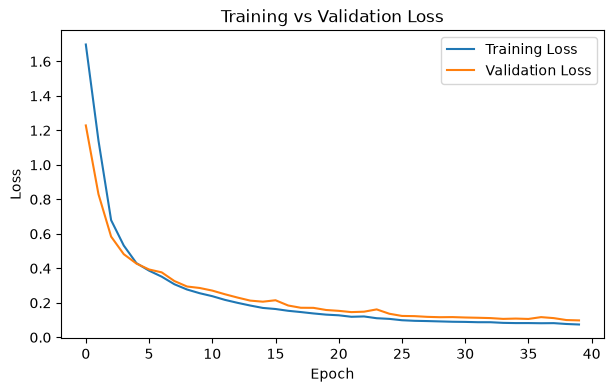

In [15]:
# Plot training and validation loss
plt.figure(figsize=(7, 4))

plt.plot(model_history.history["loss"], label="Training Loss")
plt.plot(model_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


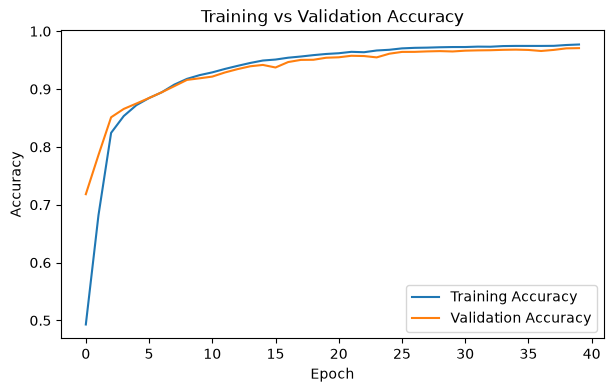

In [16]:
# Plot training and validation accuracy
plt.figure(figsize=(7, 4))

plt.plot(model_history.history["accuracy"], label="Training Accuracy")
plt.plot(model_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### What happened during this training run?

The model continued improving well beyond the original 15-epoch range.

At epoch 1:

```text
train accuracy = 49.30%
validation accuracy = 71.82%
train loss = 1.6979 
validation loss = 1.2286
```

At epoch 40:

```text
train accuracy = 97.70%
validation accuracy = 97.07%
train loss = 0.0744
validation loss = 0.0981
```

Validation loss had a few temporary increases, but the overall trend continued downward. The learning rate was reduced during training, and the model reached a new best validation loss again at **epoch 40**.

Training and validation performance remain close, so the curves do not show a large overfitting gap. At the same time, because the best validation loss occurred at the final allowed epoch, this run does not yet show a clear validation plateau or an early-stopping point.


## 11. Final evaluation on the held-out test set

The test set contains 106 image-mask pairs that were not used to update the model weights.

Two kinds of evaluation are performed:

1. `model.evaluate()` reports **test loss** and **pixel accuracy**.
2. `calculate_mean_iou()` computes **Mean Intersection over Union (mIoU)** separately.

For one class:

```text
IoU = intersection of prediction and ground truth
      --------------------------------------------
      union of prediction and ground truth
```

Mean IoU averages this overlap measure across the semantic classes that are represented in the metric calculation. It is stricter than pixel accuracy because a model must overlap the correct region rather than simply classify a large number of easy pixels correctly.

In [17]:
# Evaluate loss and accuracy on unseen test images
test_loss, test_accuracy = unet.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9766 - loss: 0.0796
Test Loss: 0.07957341521978378
Test Accuracy: 0.9765663743019104


In [18]:
def calculate_mean_iou(model, dataset, num_classes):

    # TensorFlow's built-in MeanIoU calculator
    iou_metric = tf.keras.metrics.MeanIoU(num_classes=num_classes)

    for images, true_masks in dataset:

        # Model prediction
        predictions = model.predict(images, verbose=0)

        # Convert 23 class scores into one predicted class per pixel
        predicted_masks = tf.argmax(predictions, axis=-1)

        # Remove the last dimension from the true masks
        true_masks = tf.squeeze(true_masks, axis=-1)

        # Compare true and predicted classes
        iou_metric.update_state(true_masks, predicted_masks)

    return iou_metric.result().numpy()

In [19]:
test_mean_iou = calculate_mean_iou(unet,test_dataset,NUM_CLASSES)

print("Test Mean IoU:", test_mean_iou)

2026-08-17 15:48:25.515017: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test Mean IoU: 0.57625383


### Class distribution and class-wise IoU

Pixel accuracy and Mean IoU summarize performance differently, so the next cells look more closely at **class imbalance** and **per-class overlap**.

First, the notebook counts how many training pixels belong to each class. Then it builds a test-set confusion matrix and calculates IoU separately for every class. This helps identify whether strong overall accuracy is being driven mainly by large/common classes while rare classes remain difficult.


In [20]:
# Count how many pixels belong to each class in the training set

class_pixel_counts = np.zeros(NUM_CLASSES)

for images, masks in train_dataset:

    masks = tf.squeeze(masks, axis=-1).numpy()

    for class_id in range(NUM_CLASSES):

        class_pixel_counts[class_id] += np.sum(masks == class_id)


# Convert counts to percentages
total_pixels = np.sum(class_pixel_counts)

class_percentages = (class_pixel_counts / total_pixels) * 100


# Print the results
for class_id in range(NUM_CLASSES):

    print(
        f"Class {class_id}: "
        f"{int(class_pixel_counts[class_id])} pixels "
        f"({class_percentages[class_id]:.3f}%)")

Class 0: 0 pixels (0.000%)
Class 1: 773624 pixels (7.424%)
Class 2: 37799 pixels (0.363%)
Class 3: 5751 pixels (0.055%)
Class 4: 4338 pixels (0.042%)
Class 5: 42493 pixels (0.408%)
Class 6: 157938 pixels (1.516%)
Class 7: 4518989 pixels (43.367%)
Class 8: 197024 pixels (1.891%)
Class 9: 667976 pixels (6.410%)
Class 10: 58258 pixels (0.559%)
Class 11: 134559 pixels (1.291%)
Class 12: 1081 pixels (0.010%)
Class 13: 3345170 pixels (32.103%)
Class 14: 10731 pixels (0.103%)
Class 15: 14998 pixels (0.144%)
Class 16: 8792 pixels (0.084%)
Class 17: 105751 pixels (1.015%)
Class 18: 3506 pixels (0.034%)
Class 19: 28586 pixels (0.274%)
Class 20: 6640 pixels (0.064%)
Class 21: 301 pixels (0.003%)
Class 22: 295919 pixels (2.840%)


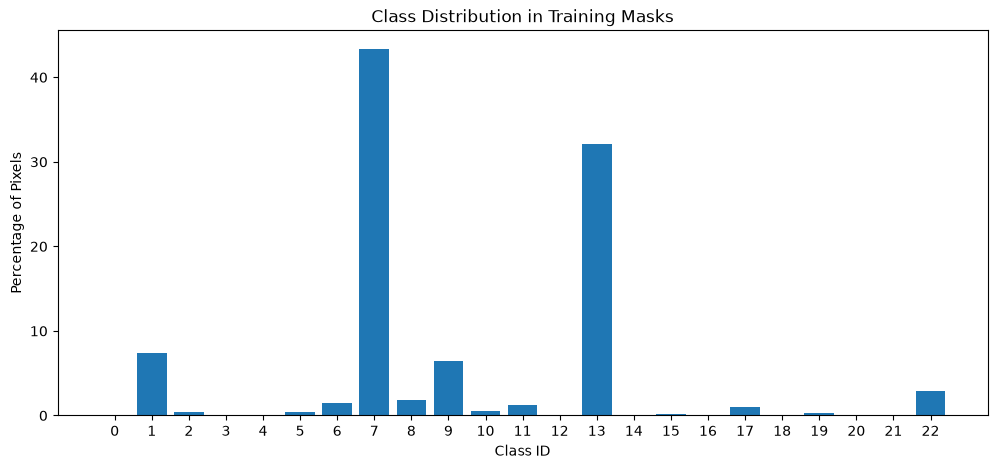

In [21]:
plt.figure(figsize=(12, 5))

plt.bar(range(NUM_CLASSES),class_percentages)

plt.xlabel("Class ID")
plt.ylabel("Percentage of Pixels")
plt.title("Class Distribution in Training Masks")

plt.xticks(range(NUM_CLASSES))

plt.show()

In [22]:
# Create a confusion matrix for all test-set pixels

confusion_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES),dtype=np.int64)


for images, true_masks in test_dataset:

    # Predict segmentation masks
    predictions = unet.predict(images,verbose=0)

    predicted_masks = tf.argmax(predictions,axis=-1)

    true_masks = tf.squeeze(true_masks,axis=-1)


    # Flatten pixels
    true_pixels = tf.reshape(true_masks,[-1])

    predicted_pixels = tf.reshape(predicted_masks,[-1])

    # Add this batch to the confusion matrix
    batch_matrix = tf.math.confusion_matrix(true_pixels,predicted_pixels,num_classes=NUM_CLASSES)

    confusion_matrix += batch_matrix.numpy()

2026-08-17 15:48:27.408483: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [23]:
per_class_iou = []

for class_id in range(NUM_CLASSES):

    true_positive = confusion_matrix[class_id,class_id]

    false_positive = (np.sum(confusion_matrix[:, class_id])- true_positive)

    false_negative = (np.sum(confusion_matrix[class_id, :])- true_positive)

    denominator = (true_positive+ false_positive+ false_negative)

    if denominator == 0:
        iou = np.nan
    else:
        iou = true_positive / denominator

    per_class_iou.append(iou)

    print(
        f"Class {class_id}: "
        f"IoU = {iou:.3f}"
    )

Class 0: IoU = nan
Class 1: IoU = 0.912
Class 2: IoU = 0.533
Class 3: IoU = 0.172
Class 4: IoU = 0.014
Class 5: IoU = 0.228
Class 6: IoU = 0.845
Class 7: IoU = 0.991
Class 8: IoU = 0.883
Class 9: IoU = 0.870
Class 10: IoU = 0.683
Class 11: IoU = 0.881
Class 12: IoU = 0.000
Class 13: IoU = 0.985
Class 14: IoU = 0.655
Class 15: IoU = 0.840
Class 16: IoU = 0.681
Class 17: IoU = 0.885
Class 18: IoU = 0.007
Class 19: IoU = 0.563
Class 20: IoU = 0.200
Class 21: IoU = 0.000
Class 22: IoU = 0.851


### Interpreting the test metrics

The held-out test results are:

```text
Test accuracy: 97.65%
Test mIoU:     0.5762
```

These numbers measure different things.

**Pixel accuracy** asks:

> Out of all test pixels, what fraction received the correct class label?

**IoU for one class** asks:

> How much does the predicted region for this class overlap the true region?

Then **Mean IoU** averages the IoU values across the classes that are represented in the metric calculation.

The class-distribution analysis shows a strong imbalance. Classes **7** and **13** alone account for about **75.47%** of the training pixels, while several classes make up far less than 0.1% each.

The class-wise IoU results reflect this uneven difficulty. Some classes are segmented very well, for example:

```text
Class 7:  IoU = 0.991
Class 13: IoU = 0.985
Class 1:  IoU = 0.912
Class 17: IoU = 0.885
```

Other very rare classes remain difficult:

```text
Class 4:  IoU = 0.014
Class 12: IoU = 0.000
Class 18: IoU = 0.007
Class 21: IoU = 0.000
```

Class 0 has no pixels in this evaluation and therefore has an undefined (`NaN`) class-wise IoU.

The gap between high pixel accuracy and lower Mean IoU therefore still matters. The model performs very strongly on many pixels and on several major classes, but performance is much less consistent across the rarest semantic classes.


## 12. Convert logits into a segmentation mask

For each pixel, the model outputs 23 class scores:

```text
pixel → [score_0, score_1, ..., score_22]
```

`tf.argmax(..., axis=-1)` finds the position of the largest score:

```text
23 scores
   ↓ argmax
one predicted class ID
```

Applying this to every pixel converts the network output from:

```text
96 × 128 × 23
```

to a segmentation mask containing one predicted class per pixel.

In [24]:
def create_mask(prediction_logits):
    predicted_classes = tf.argmax(prediction_logits, axis=-1)
    return predicted_classes[..., tf.newaxis]


## 13. Qualitative test predictions

Metrics summarize the whole test set, but segmentation results should also be inspected visually.

For held-out test examples, the notebook displays:

```text
Input RGB image → Ground-truth mask → Predicted mask
```

This makes it easier to see whether the network captures the overall scene structure and where it struggles with small objects, thin structures, boundaries, or less common classes.

In [25]:
def show_predictions(dataset, num=3):

    # Take one batch from the test dataset
    for images, masks in dataset.take(1):

        # Predict the whole batch
        predictions = unet.predict(images, verbose=0)

        # Convert class scores to class IDs
        predictions = tf.argmax(predictions, axis=-1)

        # Show the first 'num' examples
        for i in range(num):

            plt.figure(figsize=(15, 5))

            # Input image
            plt.subplot(1, 3, 1)
            plt.imshow(images[i])
            plt.title("Input Image")
            plt.axis("off")

            # True mask
            plt.subplot(1, 3, 2)
            plt.imshow(tf.squeeze(masks[i]),cmap="nipy_spectral")
            plt.title("Ground Truth")
            plt.axis("off")

            # Predicted mask
            plt.subplot(1, 3, 3)
            plt.imshow(predictions[i],cmap="nipy_spectral")
            plt.title("Prediction")
            plt.axis("off")

            plt.show()

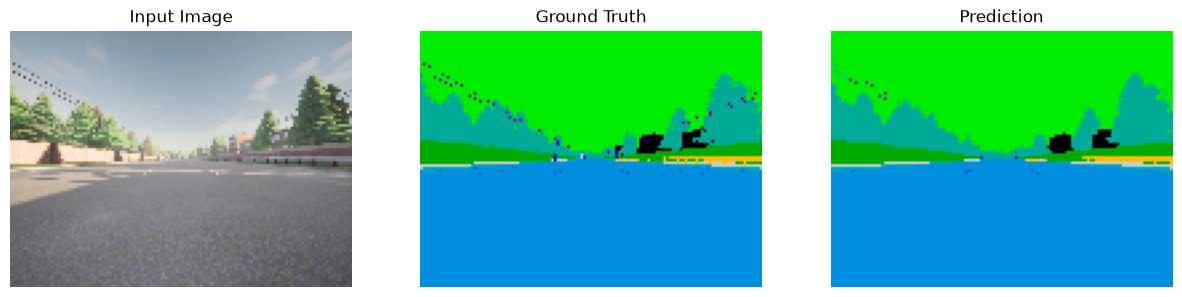

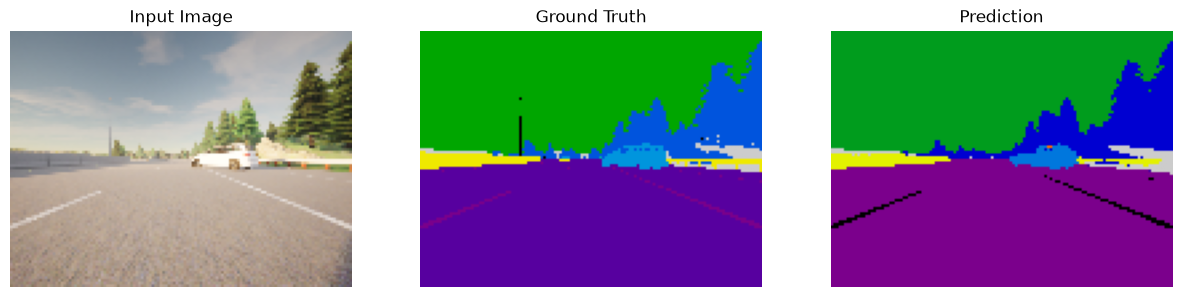

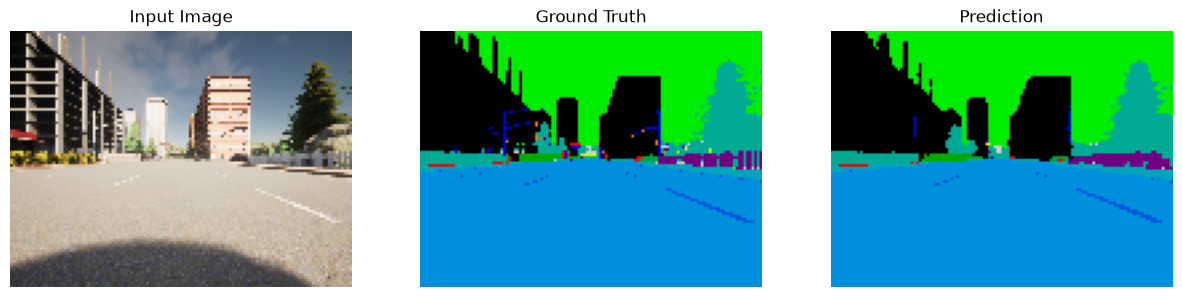

In [26]:
show_predictions(test_dataset, num=3)

### Visual interpretation

The held-out examples show that the model reproduces the **large-scale scene geometry** very well. Major road, vegetation/sky, building, and other broad regions generally line up closely with the ground-truth masks.

The remaining errors are concentrated more around **small regions, thin structures, fine boundaries, and uncommon classes**. This matches the quantitative analysis above: several common classes have very high IoU, while some of the rarest classes have very low IoU.

The visual predictions and class-wise IoU therefore tell a consistent story. The U-Net has learned the overall road-scene structure strongly, but rare semantic details remain the main weakness.


## 14. Save the trained model

`EarlyStopping` was configured with `restore_best_weights=True`.

In this run, the best validation loss occurred at **epoch 40**, which was also the final allowed epoch. Early stopping did not trigger because validation performance continued improving. The weights currently stored in `unet` therefore correspond to the best validation-loss epoch from this run.

The final model is saved in Keras format so it can be loaded later without retraining.


In [27]:
FINAL_MODEL_PATH = ARTIFACT_DIR / "unet_road_segmentation.keras"
unet.save(str(FINAL_MODEL_PATH))
print("Saved model to:", FINAL_MODEL_PATH)


Saved model to: /home/roozbeh/projects/Autonomous-driving-semantic-segmentation/artifacts/unet_road_segmentation.keras


## Results and limitations

### Test results from this run

| Metric | Result |
|---|---:|
| Test loss | **0.0795** |
| Test pixel accuracy | **97.65%** |
| Test Mean IoU | **0.5762** |

Training finished with **97.70% training accuracy** and **97.07% validation accuracy**. Validation loss reached its best value, **0.0981**, at epoch 40.

The small train-validation gap and the learning curves do not show a large overfitting problem in this run. Validation loss continued improving through the final epoch, including after several learning-rate reductions.

The additional class analysis also explains why pixel accuracy is stronger than Mean IoU. The training masks are highly imbalanced: classes **7** and **13** account for about **75.47%** of all training pixels. Several common classes achieve very high IoU, while some extremely rare classes remain difficult. For example, classes 7 and 13 reach IoUs of **0.991** and **0.985**, whereas classes 4, 12, 18, and 21 are close to zero.

The displayed test examples support the same conclusion. The model captures the overall road-scene layout very well, while some small objects, thin structures, fine boundaries, and rare semantic regions are still less reliable.

### Limitations and possible improvements

- Because the best validation loss occurred at the final allowed epoch, a short extension with the same callbacks could check whether training has fully converged before changing the architecture.
- Address the strong class imbalance with a class-aware loss strategy, such as class weighting or focal loss, and compare the effect on Mean IoU and the weakest class-wise IoUs.
- Add data augmentation, applying geometric transformations identically to each image and its mask.
- Test higher input resolution to improve fine boundaries and small structures, while considering the additional memory and training cost.
- If the images come from continuous driving sequences, a sequence-level split would provide a stricter generalization test than a random image-level split.

## Takeaway

The encoder progressively learns richer features while reducing spatial resolution. The decoder restores spatial resolution, and skip connections bring back high-resolution encoder information. Finally, the `1×1` convolution converts the learned feature vector at every pixel into class logits.

Together, these components allow U-Net to perform dense, pixel-level scene understanding rather than producing only one label or one bounding box for an image.
